# Simuladores de política cuantitativa: desviación de comercio y transmisión monetaria

**¿Cómo redirigen el gasto los aranceles y cómo cambian las respuestas del ingreso de los hogares la transmisión monetaria?**

Inspeccionamos la tabla ICIO de la OCDE incluida y ejecutamos dos modelos didácticos separados. El preset `nafta_china` usa participaciones especificadas manualmente para México, Estados Unidos y China; este código no lo calibra con la tabla ICIO cargada. El ejemplo monetario es un cálculo del modelo, no efectos de política estimados ni PMC de encuestas.

## El método en matemáticas

Con $\hat x=x'/x$, las participaciones bilaterales del gasto y los precios sectoriales satisfacen
$$\pi_{ni}^{j\prime}=\pi_{ni}^j\left(\frac{\hat\kappa_{ni}^j\hat c_i^j}{\hat P_n^j}\right)^{-\theta_j},\qquad \hat P_n^j=\left[\sum_i\pi_{ni}^j(\hat\kappa_{ni}^j\hat c_i^j)^{-\theta_j}\right]^{-1/\theta_j}.$$
Los costos combinan salarios y precios de insumos: $\hat c_i^j=\hat w_i^{\gamma_i^j}\prod_k(\hat P_i^k)^{\gamma_i^{j,k}}$. El salario real es $\hat w_n/\hat P_n$; el ingreso real del modelo es $\hat I_n/\hat P_n$ e incluye el efecto de la recaudación arancelaria.

El experimento monetario lineal descompone el consumo en
$$d\mathbf C=\mathbf J^{C,r}d\mathbf r+\mathbf J^{C,Y}d\mathbf Y,\qquad s_{\mathrm{indirecto}}=100\frac{(\mathbf J^{C,Y}d\mathbf Y)_0}{dC_0}.$$
La participación indirecta se expresa en porcentaje. El comparador RANK utilizado aquí fija el canal de ingreso en cero por construcción; es una convención de esta comparación.

## Intuición

**Intuición.** Un arancel bilateral modifica los costos relativos de abastecimiento, por lo que el gasto puede desplazarse hacia productores nacionales y de terceros países. La recaudación puede hacer que el ingreso real y el salario real cambien de forma distinta. En el modelo monetario, el consumo responde tanto a la tasa de interés como al ingreso laboral. Que el ingreso contribuya a la contracción no implica una caída total mayor que en RANK: también difieren el canal directo y la trayectoria de tasas de equilibrio.

## Código resuelto

La figura comercial incluye las compras nacionales en el gasto manufacturero total. Sus barras son participaciones de abastecimiento, no participaciones condicionadas a las importaciones.

In [1]:
# Preamble: import numerical libraries, plotting style, ICIO data loader, and policy simulators
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.trade.data import load_icio_data
from puremacro.models import (
    TradePolicySimulator,
    MonetaryTransmissionSimulator,
)

print("Quantitative Macro Policy Simulators: Trade Policy GE & Monetary Transmission")

Quantitative Macro Policy Simulators: Trade Policy GE & Monetary Transmission


In [2]:
# --- Experiment 1: Inspect Bundled 77-Country 11-Sector OECD ICIO Data Matrix ---
# Inspect the empirical inter-country input-output (ICIO) transaction foundation.
# The table contains 77 canonical economies, 11 aggregated industries, and 3 final demand
# categories, forming an 850 x 1078 structural transaction system.
icio = load_icio_data(return_structured=True)

print(f"Bundled OECD ICIO Structural Container:")
print(f"  Matrix Dimensions         : {icio.matrix.shape[0]} rows x {icio.matrix.shape[1]} columns")
print(f"  Countries Represented     : {len(icio.country_codes)} canonical economies")
print(f"  Sectors Represented       : {len(icio.sector_codes)} aggregated industries")
print(f"  Final Demand Categories   : {len(icio.fd_codes)} components per country")
print(f"  Intermediate Use Block    : {icio.matrix[:847, :847].shape}")
print(f"  Final Demand Delivery     : {icio.matrix[:847, 847:].shape}")
print(f"  Value-Added / Tax Rows    : {icio.matrix[847:, :847].shape}")

# Headline assertions validating empirical matrix dimensions and provenance
assert icio.matrix.shape == (850, 1078), "ICIO matrix must have shape (850, 1078)"
assert len(icio.country_codes) == 77, "Must contain 77 canonical countries"
assert len(icio.sector_codes) == 11, "Must contain 11 canonical sectors"
assert len(icio.fd_codes) == 3, "Must contain 3 condensed final demand categories"
assert "USA" in icio.country_codes and "CHN" in icio.country_codes and "MEX" in icio.country_codes
assert "MANU" in icio.sector_codes and "AGRI" in icio.sector_codes and "FIN" in icio.sector_codes

Bundled OECD ICIO Structural Container:
  Matrix Dimensions         : 850 rows x 1078 columns
  Countries Represented     : 77 canonical economies
  Sectors Represented       : 11 aggregated industries
  Final Demand Categories   : 3 components per country
  Intermediate Use Block    : (847, 847)
  Final Demand Delivery     : (847, 231)
  Value-Added / Tax Rows    : (3, 847)


In [3]:
# --- Experiment 2: Quantitative Trade Policy Simulator (NAFTA-China GE) ---
# Caliendo & Parro (2015) exact hat algebra Ricardian general equilibrium model with I-O linkages.
# The teaching preset specifies shares for 3 economies (MEX, USA, CHN) across 2 sectors
# (Manufactures, Services) with trade elasticities theta = [5.0, 4.0].
sim_trade = TradePolicySimulator.from_preset("nafta_china")

print("Baseline Economy Calibration:")
print(f"  Economies                 : {sim_trade.model.country_codes}")
print(f"  Sectors                   : {sim_trade.model.sector_codes}")
print(f"  Trade Elasticities (theta): {sim_trade.model.theta}")

# Simulate a unilateral 25% tariff escalation by USA on Chinese manufactured imports
res_trade = sim_trade.simulate_bilateral_tariff("USA", "CHN", tariff_rate=0.25, tol=1e-10)

idx_mex, idx_usa, idx_chn = [sim_trade.model.country_codes.index(c) for c in ("MEX", "USA", "CHN")]
base_mfg_mex = sim_trade.model.trade_shares[0, idx_usa, idx_mex]
prime_mfg_mex = res_trade.pi_prime[0, idx_usa, idx_mex]
base_mfg_chn = sim_trade.model.trade_shares[0, idx_usa, idx_chn]
prime_mfg_chn = res_trade.pi_prime[0, idx_usa, idx_chn]

print("\nGeneral Equilibrium Trade Counterfactual Results (25% US Tariff on China):")
print(f"  Solver Convergence        : {res_trade.converged} in {res_trade.iterations} iterations")
print(f"  Market Clearing Residual  : {res_trade.market_clearing_residual:.2e}")
print(f"  USA Tariff Revenue Prime  : {res_trade.tariff_revenue_prime[idx_usa]:.4f}")
print(f"  China Terms of Trade Hat  : {res_trade.terms_of_trade_hat[idx_chn]:.4f}")
print(f"  Mexico Terms of Trade Hat : {res_trade.terms_of_trade_hat[idx_mex]:.4f}")
print(f"  US Mfg Share from China   : {base_mfg_chn*100:.2f}% -> {prime_mfg_chn*100:.2f}% (Contraction)")
print(f"  US Mfg Share from Mexico  : {base_mfg_mex*100:.2f}% -> {prime_mfg_mex*100:.2f}% (Trade Diversion)")
print(f"  Mexico Real Wage Hat      : {res_trade.real_wage_hat[idx_mex]:.4f} (Welfare: +{res_trade.welfare_pct[idx_mex]:.3f}%)")
print(f"  China Welfare Impact      : {res_trade.welfare_pct[idx_chn]:.3f}%")

# General equilibrium consistency and trade diversion assertions
assert res_trade.converged is True, "Trade solver must converge"
assert res_trade.market_clearing_residual < 1e-6, "Walrasian residual must satisfy < 1e-6"
assert prime_mfg_chn < base_mfg_chn, "US imports from China must contract"
assert prime_mfg_mex > base_mfg_mex, "Trade diversion: US imports from Mexico must expand"
assert res_trade.terms_of_trade_hat[idx_chn] < 1.0, "China terms of trade must deteriorate"
assert res_trade.terms_of_trade_hat[idx_mex] > res_trade.terms_of_trade_hat[idx_chn], "Mexico ToT must outperform China"
assert res_trade.welfare_pct[idx_mex] > 0.0, "Mexico must experience positive welfare spillover"
assert res_trade.tariff_revenue_prime[idx_usa] > 0.0, "US must collect positive tariff revenue"

# Verify observable model identities; do not infer a causal welfare decomposition.
np.testing.assert_allclose(res_trade.pi_prime.sum(axis=2), 1.0, atol=1e-12)
np.testing.assert_allclose(res_trade.real_wage_hat, res_trade.w_hat / res_trade.P_index_hat)
np.testing.assert_allclose(res_trade.welfare_hat, res_trade.income_hat / res_trade.P_index_hat)

Baseline Economy Calibration:
  Economies                 : ('MEX', 'USA', 'CHN')
  Sectors                   : ('Manufactures', 'Services')
  Trade Elasticities (theta): [5. 4.]

General Equilibrium Trade Counterfactual Results (25% US Tariff on China):
  Solver Convergence        : True in 37 iterations
  Market Clearing Residual  : 6.08e-07
  USA Tariff Revenue Prime  : 212.2757
  China Terms of Trade Hat  : 0.9289
  Mexico Terms of Trade Hat : 0.9993
  US Mfg Share from China   : 14.00% -> 7.34% (Contraction)
  US Mfg Share from Mexico  : 14.00% -> 16.36% (Trade Diversion)
  Mexico Real Wage Hat      : 1.0014 (Welfare: +0.138%)
  China Welfare Impact      : -0.885%


In [4]:
# --- Experiment 3: Monetary Transmission Simulator (HANK vs RANK) ---
# Kaplan, Moll & Violante (2018) / Auclert et al. (2021) sequence-space framework.
# 25 bps quarterly interest rate tightening (magnitude = 0.0025, rho = 0.7, horizon T = 40).
sim_mon = MonetaryTransmissionSimulator(
    beta=0.985,      # Quarterly subjective discount factor
    gamma=1.0,       # CRRA coefficient of relative risk aversion
    r_ss=0.01,       # Steady-state quarterly real rate (1% = 4% annualized)
    phi_pi=1.5,      # Taylor rule inflation responsiveness
    kappa=0.1,       # New Keynesian Phillips Curve slope
    n_a=50,          # Idiosyncratic asset grid discretization points
    a_max=30.0,      # Asset grid upper boundary
)

res_mon = sim_mon.simulate_rate_shock(magnitude=0.0025, rho=0.7, T=40)

mpc_h = res_mon.mpc_deciles_hank
mpc_r = res_mon.mpc_deciles_rank

print("Monetary Transmission Dynamics (25 bps Quarterly Tightening):")
print(f"  Simulation Horizon        : {res_mon.horizon} quarters")
print(f"  HANK Decile 1 MPC (Poorest) : {mpc_h.iloc[0]:.4f} (Hand-to-mouth)")
print(f"  HANK Decile 10 MPC (Richest): {mpc_h.iloc[-1]:.4f} (Wealthy)")
print(f"  RANK Uniform MPC           : {mpc_r.iloc[0]:.4f} (Identical across deciles)")
print(f"  Aggregate Quarterly MPC    : HANK = {res_mon.aggregate_mpc_hank:.4f} vs RANK = {res_mon.aggregate_mpc_rank:.4f}")
print(f"  Impact Output Contraction  : HANK = {res_mon.irf_output_hank[0]*100:.3f}% vs RANK = {res_mon.irf_output_rank[0]*100:.3f}%")
print(f"  Impact Consumption Drop    : HANK = {res_mon.irf_consumption_hank[0]*100:.3f}% vs RANK = {res_mon.irf_consumption_rank[0]*100:.3f}%")
print(f"  KMV HANK Direct Channel    : {res_mon.direct_channel_hank[0]*100:.3f}%")
print(f"  KMV HANK Indirect Channel  : {res_mon.indirect_channel_hank[0]*100:.3f}%")
print(f"  KMV HANK Indirect Share    : {res_mon.indirect_share_hank:.2f}% of consumption response")
print(f"  KMV RANK Indirect Share    : {res_mon.indirect_share_rank:.2f}% (Identically zero)")

# Monetary transmission and MPC gradient assertions
assert res_mon.horizon == 40, "Horizon must equal 40 quarters"
assert mpc_h.iloc[0] > 0.40, "Poorest decile MPC in HANK must exceed 0.40"
assert mpc_h.iloc[-1] < 0.06, "Wealthiest decile MPC in HANK must be below 0.06"
assert np.isclose(mpc_r.iloc[0], 1.0 - sim_mon.beta), "RANK MPC must equal 1 - beta"
assert res_mon.aggregate_mpc_hank > res_mon.aggregate_mpc_rank, "HANK aggregate MPC must exceed RANK"
assert res_mon.irf_output_hank[0] < 0.0 and res_mon.irf_output_rank[0] < 0.0, "Rate hike must contract output"

# Check the linear consumption decomposition in this simulator
kmv_diff = np.abs(res_mon.irf_consumption_hank - (res_mon.direct_channel_hank + res_mon.indirect_channel_hank))
assert np.max(kmv_diff) < 1e-12, "KMV consumption identity must hold to machine precision"
assert 0.0 < res_mon.indirect_share_hank < 100.0, "Default indirect share is a percentage"
assert np.allclose(res_mon.indirect_channel_rank, 0.0, atol=1e-14), "RANK indirect channel must be identically 0.0"
assert res_mon.indirect_share_rank == 0.0, "RANK indirect share must be 0.0%"

Monetary Transmission Dynamics (25 bps Quarterly Tightening):
  Simulation Horizon        : 40 quarters
  HANK Decile 1 MPC (Poorest) : 0.6742 (Hand-to-mouth)
  HANK Decile 10 MPC (Richest): 0.0210 (Wealthy)
  RANK Uniform MPC           : 0.0150 (Identical across deciles)
  Aggregate Quarterly MPC    : HANK = 0.1027 vs RANK = 0.0150
  Impact Output Contraction  : HANK = -0.433% vs RANK = -0.448%
  Impact Consumption Drop    : HANK = -0.433% vs RANK = -0.448%
  KMV HANK Direct Channel    : -0.368%
  KMV HANK Indirect Channel  : -0.065%
  KMV HANK Indirect Share    : 15.01% of consumption response
  KMV RANK Indirect Share    : 0.00% (Identically zero)


Text(0.5, 0.99, 'Quantitative Policy Simulators: Trade Disputes & Monetary Transmission')

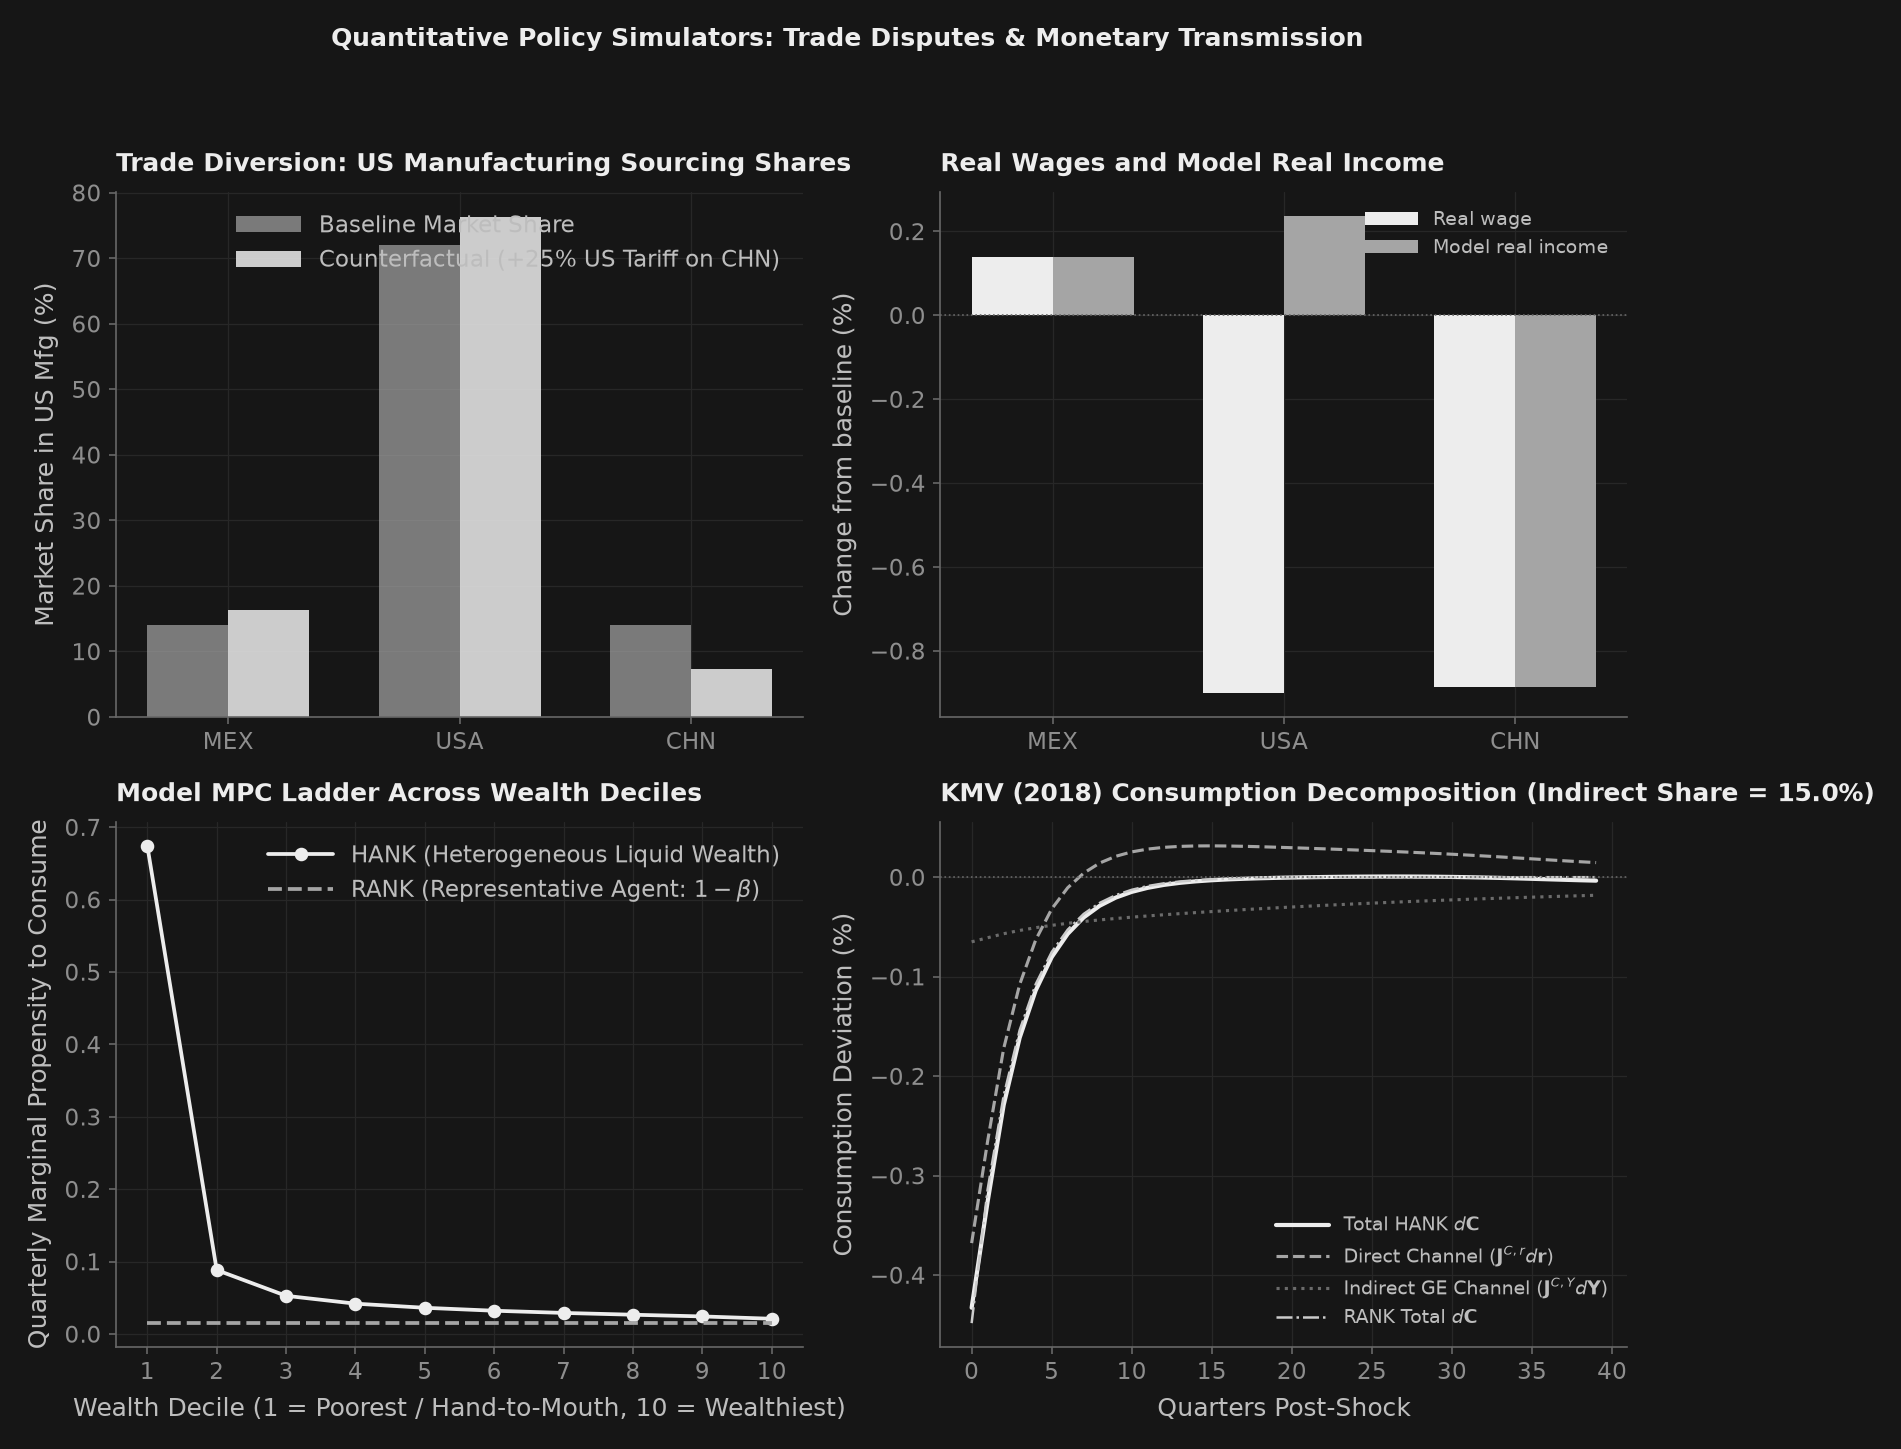

In [5]:
# --- Hero Visualizations: Quantitative Macro Policy Simulators Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Subplot 1: Trade Diversion in US Manufacturing Import Shares
ax1 = axes[0, 0]
countries = ["MEX", "USA", "CHN"]
idx_usa = 1
base_shares = [sim_trade.model.trade_shares[0, idx_usa, i] * 100 for i in range(3)]
counter_shares = [res_trade.pi_prime[0, idx_usa, i] * 100 for i in range(3)]
x = np.arange(len(countries))
width = 0.35
ax1.bar(x - width/2, base_shares, width, label="Baseline Market Share", color=_nbstyle.S2["color"], alpha=0.7)
ax1.bar(x + width/2, counter_shares, width, label="Counterfactual (+25% US Tariff on CHN)", color=_nbstyle.S1["color"], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(countries)
ax1.set_ylabel("Market Share in US Mfg (%)")
ax1.set_title("Trade Diversion: US Manufacturing Sourcing Shares")
ax1.legend(frameon=False)

# Subplot 2: Real income includes fiscal receipts; real wages do not.
ax2 = axes[0, 1]
x2 = np.arange(len(countries))
ax2.bar(x2 - width/2, 100 * (res_trade.real_wage_hat - 1), width,
        label="Real wage", color=_nbstyle.S1["color"])
ax2.bar(x2 + width/2, res_trade.welfare_pct, width,
        label="Model real income", color=_nbstyle.S2["color"])
ax2.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax2.set_xticks(x2)
ax2.set_xticklabels(countries)
ax2.set_ylabel("Change from baseline (%)")
ax2.set_title("Real Wages and Model Real Income")
ax2.legend(frameon=False, fontsize=9)

# Subplot 3: Model MPC Distribution Across 10 Wealth Deciles
ax3 = axes[1, 0]
deciles = np.arange(1, 11)
ax3.plot(deciles, res_mon.mpc_deciles_hank.values, "o-", color=_nbstyle.S1["color"], linewidth=1.8, label="HANK (Heterogeneous Liquid Wealth)")
ax3.plot(deciles, res_mon.mpc_deciles_rank.values, "--", color=_nbstyle.S2["color"], linewidth=1.8, label=r"RANK (Representative Agent: $1 - \beta$)")
ax3.set_xticks(deciles)
ax3.set_xlabel("Wealth Decile (1 = Poorest / Hand-to-Mouth, 10 = Wealthiest)")
ax3.set_ylabel("Quarterly Marginal Propensity to Consume")
ax3.set_title("Model MPC Ladder Across Wealth Deciles")
ax3.legend(frameon=False)

# Subplot 4: Kaplan-Moll-Violante (2018) Direct vs Indirect Transmission
ax4 = axes[1, 1]
quarters = np.arange(res_mon.horizon)
ax4.plot(quarters, res_mon.irf_consumption_hank * 100, color=_nbstyle.S1["color"], linewidth=2.0, label=r"Total HANK $d\mathbf{C}$")
ax4.plot(quarters, res_mon.direct_channel_hank * 100, "--", color=_nbstyle.S2["color"], linewidth=1.5, label=r"Direct Channel ($\mathbf{J}^{C,r} d\mathbf{r}$)")
ax4.plot(quarters, res_mon.indirect_channel_hank * 100, ":", color=_nbstyle.S3["color"], linewidth=1.5, label=r"Indirect GE Channel ($\mathbf{J}^{C,Y} d\mathbf{Y}$)")
ax4.plot(quarters, res_mon.irf_consumption_rank * 100, "-.", color=_nbstyle.S4["color"], linewidth=1.2, label=r"RANK Total $d\mathbf{C}$")
ax4.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax4.set_xlabel("Quarters Post-Shock")
ax4.set_ylabel("Consumption Deviation (%)")
ax4.set_title(f"KMV (2018) Consumption Decomposition (Indirect Share = {res_mon.indirect_share_hank:.1f}%)")
ax4.legend(frameon=False, fontsize=9)

fig.suptitle("Quantitative Policy Simulators: Trade Disputes & Monetary Transmission", fontsize=12, fontweight="bold", y=0.99)

## Lectura de los resultados

El panel superior izquierdo muestra cómo este preset desplaza gasto manufacturero de China hacia México y proveedores estadounidenses. El superior derecho compara el ingreso real del modelo con el salario real; la recaudación estadounidense ayuda a explicar sus signos diferentes. Son resultados condicionales del modelo, no pronósticos para los países nombrados.

Las PMC del panel inferior izquierdo se calculan con el modelo de hogares. Consulte los valores impresos de esta ejecución sin interpretar una calibración como estimación empírica. El panel inferior derecho suma los canales directo y de ingreso para obtener la respuesta HANK del consumo. Con los parámetros iniciales, la contracción de impacto HANK es ligeramente menor que la de RANK pese al canal indirecto positivo. La identidad comprueba la suma numérica, no la adecuación empírica del modelo.

No usamos `welfare_decomposition`: su componente `tariff_revenue` se calcula como residuo, por lo que una suma exacta no demuestra una descomposición causal en términos de intercambio, eficiencia y recaudación.

## Tu turno

In [6]:
# Your turn: counterfactual trade dispute tariffs and monetary policy transmission
# Modify the parameters below to explore different bilateral trade tariff rates,
# monetary policy interest rate shock sizes, and shock persistence parameters.

# ← change this: bilateral tariff rate on Chinese manufactured goods (e.g. 0.10 to 0.50)
tariff_rate_custom = 0.25

# ← change this: monetary policy rate shock magnitude in quarterly rate (0.0025 = +25 bps / +100 bps annualized)
shock_magnitude_custom = 0.0025

# ← change this: persistence of monetary rate shock rho (e.g. 0.5 to 0.85)
shock_rho_custom = 0.70

# Validate inputs before invoking the solvers.
assert 0.0 < tariff_rate_custom <= 1.0
assert 0.0 < shock_magnitude_custom <= 0.02
assert 0.0 <= shock_rho_custom < 1.0

# Execute custom trade policy counterfactual
custom_trade_res = sim_trade.simulate_bilateral_tariff("USA", "CHN", tariff_rate=tariff_rate_custom)

# Execute custom monetary policy transmission simulation
custom_mon_res = sim_mon.simulate_rate_shock(
    magnitude=shock_magnitude_custom,
    rho=shock_rho_custom,
    T=40,
)

print(f"Custom Trade Simulation (US Tariff on China = {tariff_rate_custom*100:.1f}%):")
print(f"  Converged                 : {custom_trade_res.converged}")
print(f"  Market Clearing Residual  : {custom_trade_res.market_clearing_residual:.2e}")
print(f"  Mexico Real Wage Hat      : {custom_trade_res.real_wage_hat[0]:.4f} (Welfare: {custom_trade_res.welfare_pct[0]:+.3f}%)")
print(f"  USA Real Wage Hat         : {custom_trade_res.real_wage_hat[1]:.4f} (Welfare: {custom_trade_res.welfare_pct[1]:+.3f}%)")
print(f"  China Real Wage Hat       : {custom_trade_res.real_wage_hat[2]:.4f} (Welfare: {custom_trade_res.welfare_pct[2]:+.3f}%)")

print(f"\nCustom Monetary Transmission (Shock = +{shock_magnitude_custom*40000:.0f} bps ann, rho = {shock_rho_custom:.2f}):")
print(f"  HANK Output Contraction   : {custom_mon_res.irf_output_hank[0]*100:.3f}% (RANK: {custom_mon_res.irf_output_rank[0]*100:.3f}%)")
print(f"  HANK Consumption Drop     : {custom_mon_res.irf_consumption_hank[0]*100:.3f}% (RANK: {custom_mon_res.irf_consumption_rank[0]*100:.3f}%)")
print(f"  KMV HANK Indirect Share   : {custom_mon_res.indirect_share_hank:.1f}% of total consumption decline")

# Downstream assertions validating custom parameters and economic consistency
assert custom_trade_res.converged is True, "Custom trade simulation must converge"
assert custom_trade_res.market_clearing_residual < 1e-6, "Custom trade residual must be < 1e-6"
assert 0.0 < tariff_rate_custom <= 1.0, "Tariff rate must be positive and <= 100%"
assert 0.0 < shock_magnitude_custom <= 0.02, "Shock magnitude must be positive and <= 200 bps"
assert 0.0 <= shock_rho_custom < 1.0, "Shock persistence rho must lie in [0, 1)"
assert custom_mon_res.irf_output_hank[0] < 0.0, "HANK output must contract under positive rate shock"
assert custom_mon_res.irf_output_rank[0] < 0.0, "RANK output must contract under positive rate shock"
assert np.all(np.abs(custom_mon_res.irf_consumption_hank - (custom_mon_res.direct_channel_hank + custom_mon_res.indirect_channel_hank)) < 1e-12), "KMV identity must hold"

Custom Trade Simulation (US Tariff on China = 25.0%):
  Converged                 : True
  Market Clearing Residual  : 6.08e-07
  Mexico Real Wage Hat      : 1.0014 (Welfare: +0.138%)
  USA Real Wage Hat         : 0.9910 (Welfare: +0.237%)
  China Real Wage Hat       : 0.9911 (Welfare: -0.885%)

Custom Monetary Transmission (Shock = +100 bps ann, rho = 0.70):
  HANK Output Contraction   : -0.433% (RANK: -0.448%)
  HANK Consumption Drop     : -0.433% (RANK: -0.448%)
  KMV HANK Indirect Share   : 15.0% of total consumption decline


**Ejercicios.**
1. *Básico:* Compare aranceles de 10% y 45%. Reporte participaciones manufactureras, recaudación, salarios reales e ingreso real del modelo. Compruebe si un arancel mayor también eleva la recaudación.
2. *Intermedio:* Duplique `shock_magnitude_custom` manteniendo la persistencia fija. ¿Se duplica la respuesta lineal? Después varíe la persistencia y compare las respuestas totales HANK y RANK.
3. *Avanzado:* Ejecute `sim_trade.simulate_trade_war(["USA"], ["CHN"], tariff_rate_a=0.25, tariff_rate_b=0.25)`. Compruebe si la represalia invierte el orden del experimento unilateral, sin presuponer el resultado.

## ¿Qué tan exhaustivo es esto?

`TradePolicySimulator` ilustra un modelo comercial pequeño de cambios exactos; `load_icio_data` expone por separado la tabla empírica incluida. `MonetaryTransmissionSimulator` compara respuestas locales HANK/RANK y `puremacro.models.hank_sequence_space` proporciona los jacobianos de hogares. El cuaderno 63 demuestra bienestar Hicksiano del consumo con sus preferencias y cierre contable explícitamente admitidos.